# 03 — RFM and Cohort Analysis

*Executed analytical companion to the validated production pipeline.*

## Objective

Explain the validated customer RFM, eight rule-based segments, recommended actions, and monthly cohort-retention view without rebuilding customer logic.

## Business Questions

- How are recency, frequency, and monetary value defined and scored?
- Which customer groups dominate count and revenue?
- What actions are associated with each transparent rule-based segment?
- How should retention cohorts and the partial final month be interpreted?

## Inputs

- `data/processed/customer_rfm_segments.parquet`
- `reports/customer_analytics/segment_summary.csv`
- `reports/customer_analytics/segment_action_plan.csv`
- `reports/customer_analytics/cohort_retention.csv`
- Reusable segment rules from `retail_analytics.customer_analytics`

## Methodology

Read the production RFM table and aggregated customer reports. Only distributions and small samples are displayed; no full customer-level table is printed.

## Code

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "src" / "retail_analytics").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_rows", 12)
pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 140)

def load_json(relative_path):
    return json.loads((PROJECT_ROOT / relative_path).read_text(encoding="utf-8"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")

from retail_analytics.customer_analytics import SEGMENT_ORDER, SEGMENT_RULES

summary = load_json("reports/customer_analytics_summary.json")
rfm_path = PROJECT_ROOT / "data" / "processed" / "customer_rfm_segments.parquet"
rfm = pd.read_parquet(
    rfm_path,
    columns=["recency_days", "frequency_orders", "monetary_value_gbp", "segment"],
)
print(f"Validated customer rows: {len(rfm):,.0f}")
print("Snapshot date:", summary["snapshot_date"])

Project root: C:\Projects\Retail-Customer-Intelligence-Analytics
Python: 3.12.7
Validated customer rows: 5,878
Snapshot date: 2011-12-10


In [2]:
rfm_distribution = rfm[["recency_days", "frequency_orders", "monetary_value_gbp"]].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90]
).loc[["count", "mean", "25%", "50%", "75%", "90%", "max"]]
rfm_distribution["monetary_value_gbp"] = rfm_distribution["monetary_value_gbp"].map(
    lambda value: f"GBP {value:,.2f}"
)
display(rfm_distribution)

rules = pd.DataFrame(
    [(segment, SEGMENT_RULES[segment]) for segment in SEGMENT_ORDER],
    columns=["Segment", "Ordered assignment rule"],
)
display(rules)

,recency_days,frequency_orders,monetary_value_gbp
count,5878.000000,5878.000000,"GBP 5,878.00"
mean,201.866791,6.289384,"GBP 2,955.90"
25%,26.000000,1.000000,GBP 342.28
50%,96.000000,3.000000,GBP 867.74
75%,380.000000,7.000000,"GBP 2,248.30"
90%,535.300000,13.000000,"GBP 5,465.74"
max,739.000000,398.000000,"GBP 580,987.04"


,Segment,Ordered assignment rule
0,Champions,"R >= 4, F >= 4, M >= 4, and at least 2 complet..."
1,Loyal Customers,"R >= 3, F >= 4, M >= 3, and at least 2 complet..."
2,Potential Loyalists,"R >= 4, F between 2 and 3, M >= 2, and at leas..."
3,New Customers,R >= 4 and exactly 1 completed order.
4,Cannot Lose Them,"R <= 2, F >= 4, M >= 4, and at least 2 complet..."
5,At Risk,R <= 2 and either F >= 3 or M >= 3.
6,Hibernating,"R <= 2, F <= 2, and M <= 2."
7,Need Attention,All remaining customers after the ordered rule...


RFM formulas use the 2011-12-10 snapshot date:

- **Recency:** days from the snapshot to the customer's last completed purchase; lower is better.
- **Frequency:** distinct completed invoices; higher is better.
- **Monetary value:** identified completed-sales revenue in GBP; higher is better.
- Each metric is converted to a 1–5 quantile score before the ordered, mutually exclusive business rules are applied.

Anonymous completed sales are excluded because a missing customer ID cannot support purchase history, repeat behavior, segment assignment, or cohort membership. Their revenue remains included in aggregate sales analysis.

## Results

In [3]:
segments = pd.read_csv(PROJECT_ROOT / "reports" / "customer_analytics" / "segment_summary.csv")
segment_view = segments[
    ["segment", "customer_count", "customer_share_pct", "monetary_value_gbp", "revenue_share_pct",
     "median_recency_days", "average_frequency_orders"]
].copy()
segment_view["customer_count"] = segment_view["customer_count"].map(lambda value: f"{value:,.0f}")
segment_view["customer_share_pct"] = segment_view["customer_share_pct"].map(lambda value: f"{value:.2f}%")
segment_view["monetary_value_gbp"] = segment_view["monetary_value_gbp"].map(lambda value: f"GBP {value:,.2f}")
segment_view["revenue_share_pct"] = segment_view["revenue_share_pct"].map(lambda value: f"{value:.2f}%")
segment_view["average_frequency_orders"] = segment_view["average_frequency_orders"].map(lambda value: f"{value:.2f}")
display(segment_view)

actions = pd.read_csv(PROJECT_ROOT / "reports" / "customer_analytics" / "segment_action_plan.csv")
display(actions[["segment", "priority", "recommended_action"]])

,segment,customer_count,customer_share_pct,monetary_value_gbp,revenue_share_pct,median_recency_days,average_frequency_orders
0,Champions,"1,290",21.95%,"GBP 11,830,969.59",68.09%,17.0,17.15
1,Loyal Customers,656,11.16%,"GBP 1,861,448.10",10.71%,79.0,7.97
2,Potential Loyalists,580,9.87%,"GBP 775,456.97",4.46%,24.0,2.81
3,New Customers,235,4.00%,"GBP 79,732.19",0.46%,30.0,1.00
4,Cannot Lose Them,223,3.79%,"GBP 982,122.18",5.65%,330.0,8.98
5,At Risk,846,14.39%,"GBP 939,465.83",5.41%,387.0,2.92
6,Hibernating,"1,282",21.81%,"GBP 324,429.03",1.87%,440.0,1.19
7,Need Attention,766,13.03%,"GBP 581,180.37",3.34%,89.0,2.31


,segment,priority,recommended_action
0,Champions,Protect,"Protect with early access, premium service, an..."
1,Loyal Customers,Grow,"Use loyalty rewards, replenishment reminders, ..."
2,Potential Loyalists,Nurture,Nurture with second-next-purchase offers and c...
3,New Customers,Onboard,"Send onboarding, product education, and a time..."
4,Cannot Lose Them,Recover,Prioritise personal reactivation and service r...
5,At Risk,Win back,Trigger win-back journeys based on past catego...
6,Hibernating,Test,Use low-cost reactivation tests and suppress i...
7,Need Attention,Monitor,Monitor behaviour and use light-touch merchand...


In [4]:
cohort = pd.read_csv(PROJECT_ROOT / "reports" / "customer_analytics" / "cohort_retention.csv")
cohort_preview = cohort.iloc[:8, :9].copy()
for column in cohort_preview.columns[1:]:
    cohort_preview[column] = cohort_preview[column].map(
        lambda value: "—" if pd.isna(value) else f"{value:.1f}%"
    )
display(cohort_preview)
print(summary["cohort_retention"]["partial_month_note"])

,acquisition_month,month_0,month_1,month_2,month_3,month_4,month_5,month_6,month_7
0,2009-12,100.0%,35.3%,33.4%,42.5%,38.0%,35.9%,37.7%,34.2%
1,2010-01,100.0%,20.6%,31.1%,30.6%,26.4%,30.0%,25.9%,23.0%
2,2010-02,100.0%,23.8%,22.5%,29.1%,24.6%,20.1%,19.2%,28.6%
3,2010-03,100.0%,19.0%,23.0%,24.1%,23.2%,20.3%,24.6%,30.2%
4,2010-04,100.0%,19.4%,19.4%,16.3%,18.4%,22.4%,27.6%,26.2%
5,2010-05,100.0%,15.8%,16.9%,17.3%,17.7%,25.6%,21.3%,12.6%
6,2010-06,100.0%,17.4%,18.9%,20.4%,23.0%,28.5%,12.6%,8.9%
7,2010-07,100.0%,15.6%,18.3%,29.6%,29.0%,14.0%,11.3%,14.5%


December 2011 contains purchases only through 2011-12-09; any retention cell whose purchase month is 2011-12 is partial.


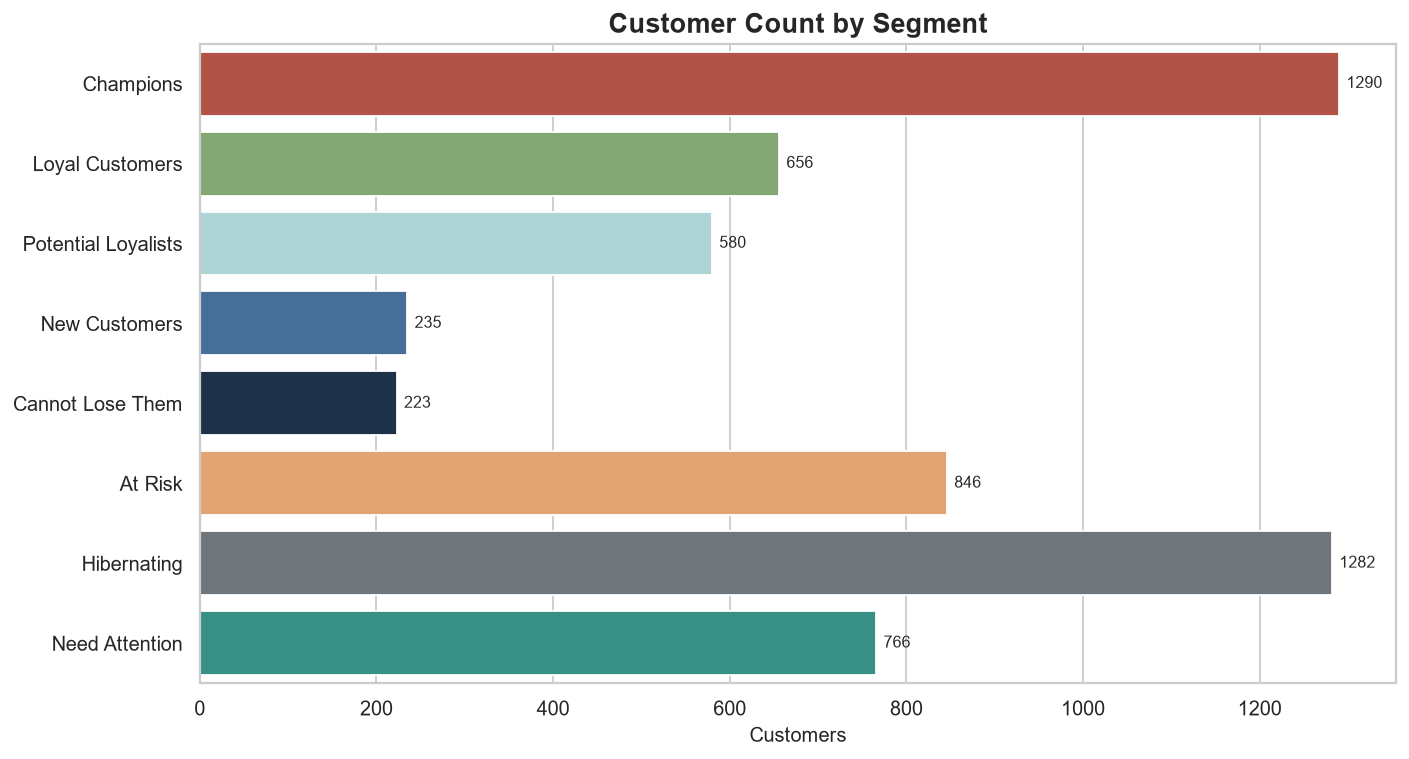

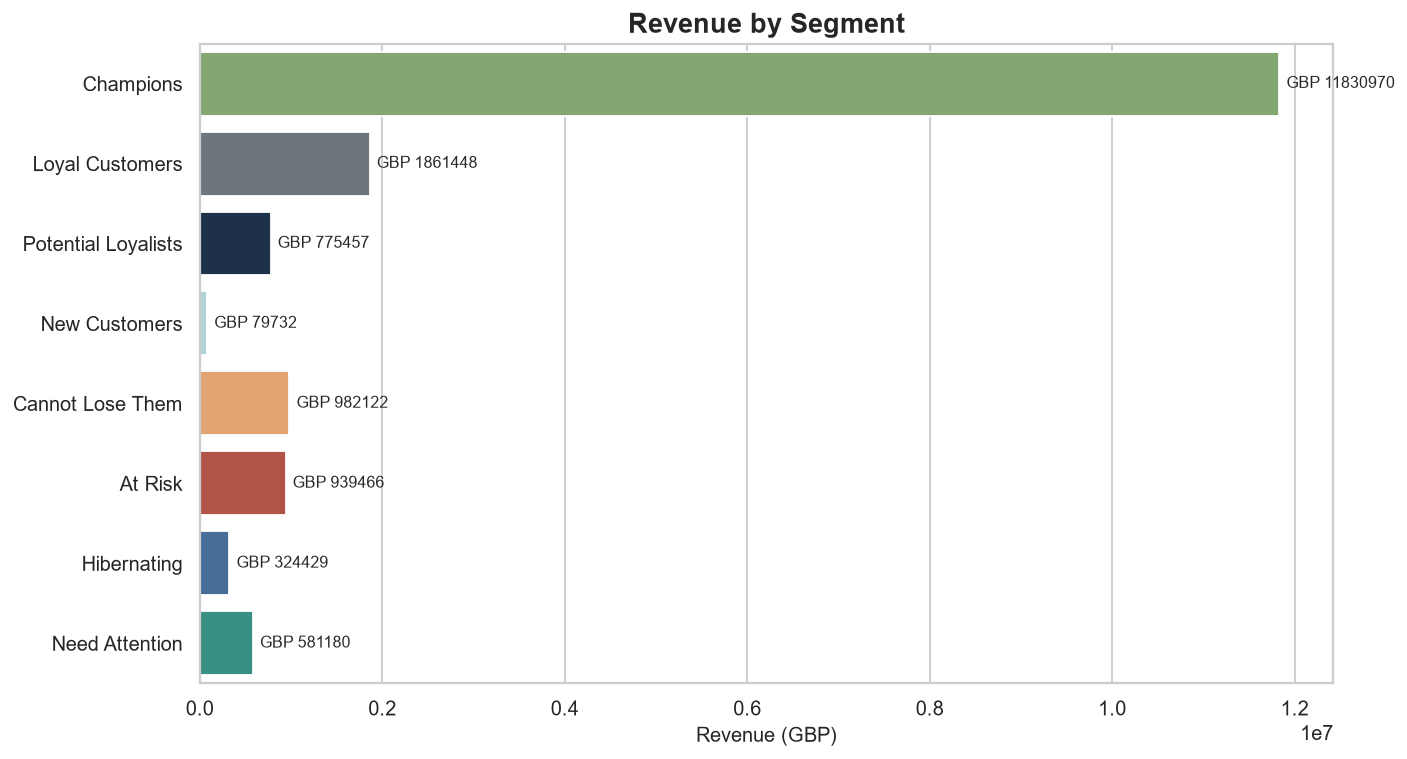

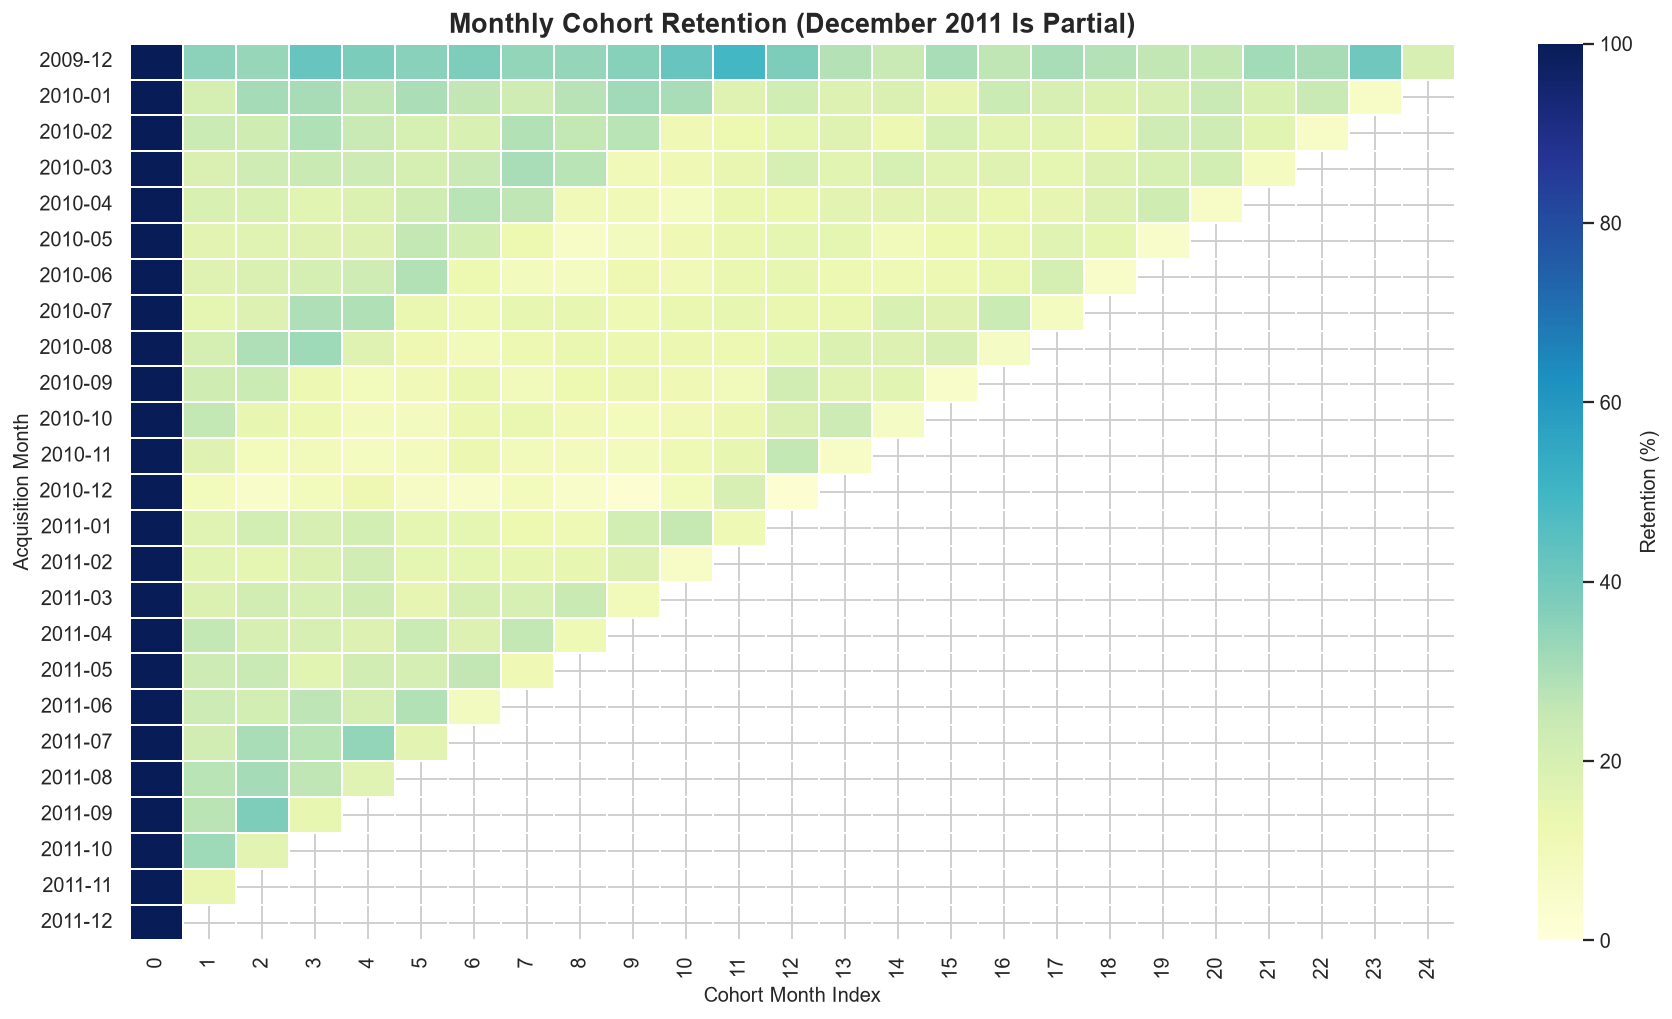

In [5]:
for chart in [
    "images/customer_analytics/02_customer_count_by_segment.png",
    "images/customer_analytics/03_revenue_by_segment.png",
    "images/customer_analytics/04_cohort_retention_heatmap.png",
]:
    display(Image(filename=str(PROJECT_ROOT / chart), width=850))

## Business Insights

- Champions account for about 22% of customers but 68% of identified-customer revenue, showing strong value concentration.
- Hibernating customers are numerous but contribute a small revenue share; low-cost testing is more proportionate than blanket discounting.
- Rule ordering matters: every customer receives exactly one interpretable segment and action.
- Cohort month 0 is 100% by construction. Cells whose purchase month is December 2011 are partial because data stop on 9 December and should not be compared with complete-month retention cells.

## Assumptions

- The snapshot is one day after the latest observed invoice date.
- Completed identified sales are the valid basis for RFM and cohort membership.
- Segment actions are hypotheses for business use, not measured treatment effects.

## Limitations

- The observation window gives customers unequal exposure time.
- No verified churn label, demographics, acquisition source, or campaign response is available.
- Cohort retention measures observed purchasing, not customer sentiment or profitability.

## Next Steps

- Validate segment actions through controlled experiments.
- Refresh RFM scores on a consistent cadence with a clearly documented snapshot.
- Track complete-month cohort cells separately from partial refresh periods.